In [1]:
import scanpy as sc
import scvi
import numpy as np
import sys
sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "../../data/obesity_subset_CEBPB_KIF11.h5ad"
)

print(adata)

adata_hvg, hvg_genes = subset_to_hvg(
    adata,
    hvg_path="../../data/preprocessed/HVG/hvg10000_genes.txt"
)

print(adata_hvg)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 24325 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'
HVG requested: 10000
HVG found in dataset: 10000
Missing genes: 0
AnnData object with n_obs × n_vars = 24325 × 10000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'


In [2]:
train_perts = [
    "NC",
    "NC+NC",
    "CEBPB",
    "KIF11",
    "CEBPB+NC",
    "KIF11+NC"
]

adata_train = adata_hvg[
    adata_hvg.obs["gene"].isin(train_perts)
].copy()

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import joblib


def compute_pca_latent(
    adata,
    d=512,
    seed=42,
):
    
    # HVG matrix
    X_hvg = adata.X
    
    if not isinstance(X_hvg, np.ndarray):
        X_hvg = X_hvg.toarray()

    pca = PCA(
        n_components=d,
        random_state=seed
    )

    X_latent = pca.fit_transform(X_hvg)

    # store in adata
    adata.obsm["X_pca"] = X_latent

    # save PCA for inverse transform
    joblib.dump(
        pca,
        f"pca_{d}.joblib"
    )

    return adata, pca


adata_train, scaler = compute_pca_latent(adata_train, 512)

print(adata_train.obsm["X_pca"].shape)

(24283, 1024)


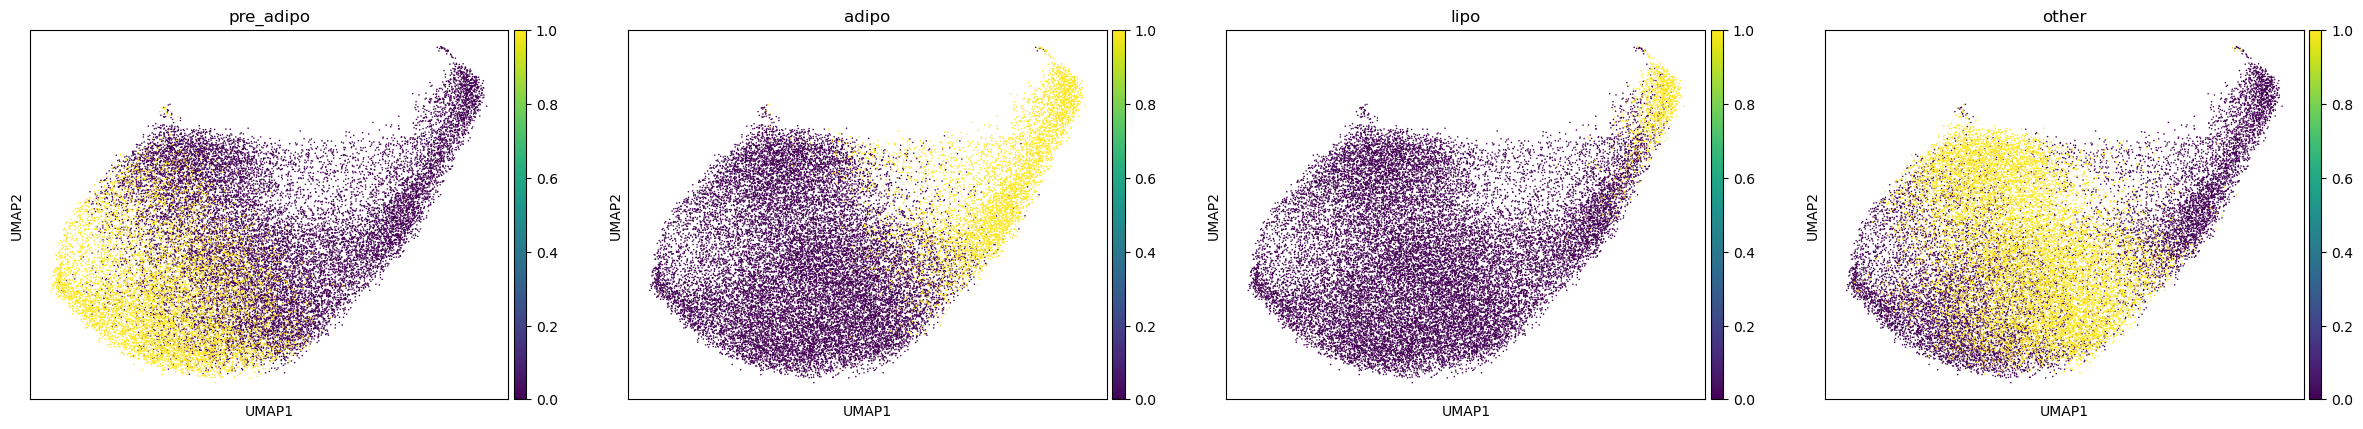

In [66]:
import scanpy as sc

adata_vis = adata_train.copy()

# 使用 PCA latent
adata_vis.obsm["X_pca"] = adata_train.obsm["X_pca"]

sc.pp.neighbors(
    adata_vis,
    use_rep="X_pca",
    n_neighbors=30,
    metric="euclidean"
)

sc.tl.umap(
    adata_vis,
    min_dist=0.3
)
sc.pl.umap(
    adata_vis,
    color=[
        "pre_adipo",
        "adipo",
        "lipo",
        "other"
    ],
    cmap="viridis",
    vmin=0,
    vmax=1
)

In [52]:
import sys
sys.path.append('../')
from scripts.pairing import assign_state_label, build_pairs_from_anndata
adata_train.obs["state"] = assign_state_label(
    adata_train.obs
)

pairs = build_pairs_from_anndata(
    adata_train,
        # verbose=True

)

print(len(pairs))

CEBPB 8660 random
CEBPB+NC 2296 all-pairs
CEBPB+NC 6724 random (NC fallback)
KIF11 4705 random
KIF11+NC 728 all-pairs
KIF11+NC 676 random (NC fallback)
23789


In [53]:
from scripts.flow_dataset import FlowPairDataset
import torch
dataset = FlowPairDataset(pairs)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=256,
    shuffle=True
)

In [54]:
from scripts.flow_model import FlowMLP
latent_dim = pairs[0]["z0"].shape[0]

cond_dim = pairs[0]["cond"].shape[0]

model = FlowMLP(

    latent_dim,

    cond_dim
)

In [55]:
from scripts.flow_loss import flow_matching_loss_pairs, flow_matching_loss_gaussian
device = "mps"

model.to(device)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3
)
for epoch in range(550):
    
    losses = []

    for z0, z1, cond in loader:

        z0 = z0.to(device)

        z1 = z1.to(device)

        cond = cond.to(device)

        loss = flow_matching_loss_pairs(

            model,

            z0,

            z1,

            cond
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        losses.append(
            loss.item()
        )

    if epoch % 20 == 0:

        print(
            epoch,
            sum(losses)/len(losses)
        )

0 8.578049270055628
20 4.840668780829317
40 4.270658318714429
60 4.01763452253034
80 3.879200340599142
100 3.791815609060308
120 3.71775508183305
140 3.6665094924229447
160 3.6194157446584394
180 3.596167500301074
200 3.5671485008731967
220 3.54286027467379
240 3.5110752403095202
260 3.507764385592553
280 3.478606131768996
300 3.4551753228710544
320 3.4615196643337125
340 3.4409417798442226
360 3.4268614707454557
380 3.4335469533038396
400 3.408166770012148
420 3.3994690218279437
440 3.3838263301439184
460 3.3780041715150237
480 3.3630864081844205
500 3.3709357759003997
520 3.360965936414657
540 3.3596939168950564


In [56]:
def sample_flow(
    model,
    z0,
    cond,
    n_steps=300
):

    device = next(model.parameters()).device

    z = z0.to(device)

    cond = cond.to(device)

    dt = 1.0/n_steps

    for i in range(n_steps):

        t = torch.ones(

            len(z),

            1,

            device=device

        ) * (i/n_steps)

        v = model(
            z,
            t,
            cond
        )

        z = z + dt*v

    return z

In [59]:
import scanpy as sc
import torch
import joblib
import numpy as np

control_path = "../../data/preprocessed/control_cells/NC_NC_control_cells.h5ad"

adata_ctrl = sc.read_h5ad(control_path)

adata_ctrl_hvg, hvg_genes = subset_to_hvg(
    adata_ctrl,
    hvg_path="../../data/preprocessed/HVG/hvg10000_genes.txt"
)


print(adata_ctrl_hvg)
pca = joblib.load("pca_1024.joblib")

X_ctrl = adata_ctrl_hvg.X

if not isinstance(X_ctrl, np.ndarray):
    X_ctrl = X_ctrl.toarray()

z_NCNC = pca.transform(X_ctrl)

print(z_NCNC.shape)

HVG requested: 10000
HVG found in dataset: 10000
Missing genes: 0
AnnData object with n_obs × n_vars = 100 × 10000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo', 'state'
    layers: 'counts'
(100, 1024)


In [60]:
import sys
sys.path.append('../')
from scripts.pairing import encode_condition

cond_combo = encode_condition(
    "CEBPB+KIF11"
)

cond_combo = torch.tensor(

    cond_combo,

    dtype=torch.float32

).unsqueeze(0)

z_source = torch.tensor(

    z_NCNC,

    dtype=torch.float32
)

cond_batch = cond_combo.repeat(

    len(z_source),

    1
)

z_pred = sample_flow(

    model,

    z_source,

    cond_batch,
    n_steps=1000
)

In [61]:
gene_pred = pca.inverse_transform(
    z_pred.detach().cpu().numpy()
)
gene_pred[gene_pred < 0] = 0
print(gene_pred.shape)

(100, 10000)


In [62]:
from scripts.scoring import reconstruct_full_expression_with_control
X_ctrl_full = adata_ctrl.X

if not isinstance(X_ctrl_full, np.ndarray):
    X_ctrl_full = X_ctrl_full.toarray()
    
X_pred_full = reconstruct_full_expression_with_control(

    adata_full = adata,   # full gene space
    adata_hvg  = adata_ctrl_hvg,

    X_hvg_rec  = gene_pred,

    X_ctrl_sample = X_ctrl_full[:len(gene_pred)]

)

In [ ]:
from scripts.save_predict import save_prediction_h5ad
prediction_h5ad_file_path = "prediction.h5ad"
adata_pred = save_prediction_h5ad(

    X_pred_full = X_pred_full,

    adata_full = adata,

    predict_perturbations = ['CEBPB+KIF11'],

    genes_to_predict_path = "../../data/predict_genes_2.txt",

    prediction_h5ad_file_path = prediction_h5ad_file_path,

)

In [63]:
import pandas as pd

centroid_df = pd.read_csv(
    "../../data/preprocessed/centroid/centroid-CEBPB_KIF11.csv",
    index_col=0
)
single_centroid = centroid_df.loc["single_centroid"].values
double_centroid = centroid_df.loc["double_centroid"].values

target_pert = "CEBPB+KIF11"

n_guides = len(target_pert.split("+"))

if n_guides == 1:

    perturbed_centroid = single_centroid

elif n_guides == 2:

    perturbed_centroid = double_centroid

In [64]:
adata = sc.read_h5ad(
    "../../data/obesity_subset_CEBPB_KIF11.h5ad"
)

mask_gt = (

    adata.obs["gene"]

    == target_pert

)

X_gt_full = adata[mask_gt].X

if not isinstance(X_gt_full, np.ndarray):

    X_gt_full = X_gt_full.toarray()


X_gt_full = X_gt_full[:len(X_pred_full)]

print("GT shape:", X_gt_full.shape)

GT shape: (42, 36601)


In [65]:
from scripts.scoring import  pearson_score,mmd_metric

pearson_score = pearson_score(

    X_gt_full,
    X_pred_full,
    perturbed_centroid

)

mmd_score = mmd_metric(

    X_gt_full,
    X_pred_full

)


print("\nRESULT")

print("pearson_delta:", pearson_score)

print("mmd:", mmd_score)


RESULT
pearson_delta: 0.3950252983301368
mmd: 0.24005409677488956


In [ ]:
from scripts.scoring import  pearson_score,mmd_metric

pearson_score = pearson_score(

    X_gt_full,
    X_pred_full,
    perturbed_centroid

)

mmd_score = mmd_metric(

    X_gt_full,
    X_pred_full

)


print("\nRESULT")

print("pearson_delta:", pearson_score)

print("mmd:", mmd_score)


RESULT
pearson_delta: 0.4060446564699125
mmd: 0.2429824289852016
